In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
! pip install -q kaggle

In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c problem1-bank-customer-churn-prediction


problem1-bank-customer-churn-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/problem1-bank-customer-churn-prediction.zip

Archive:  /content/problem1-bank-customer-churn-prediction.zip
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
df1=pd.read_csv('/content/train.csv')
train=df1.copy()


In [ ]:
df1['Exited'].value_counts()

,count
Exited,
0,10810
1,2691


In [ ]:
test= pd.read_csv('/content/test.csv')
frames = [train,test]
df = pd.concat(frames)


In [ ]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1494,14995,15693817.0,Kerr,588,France,Female,43,3,0.00,1,1,0,163471.01,NaN
1495,14996,15672640.0,Bogle,594,Germany,Male,40,8,136623.19,1,1,0,145796.49,NaN
1496,14997,15800295.0,Hsieh,684,France,Male,52,6,146758.24,3,1,0,90280.70,NaN
1497,14998,15695792.0,Hsing,684,Spain,Male,45,3,0.00,1,1,0,106095.82,NaN
1498,14999,15791216.0,Chiu,637,Germany,Male,45,1,118098.62,1,0,0,144413.92,NaN


In [ ]:
train.shape, test.shape, df.shape

((13501, 14), (1499, 13), (15000, 14))

In [ ]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,France,Male,33,5,0.0,2,1,1,145562.40,0.0
1,1,15803032.0,Hsiung,653,Germany,Female,34,1,152532.3,1,1,0,67972.45,0.0
2,2,15631170.0,Walker,656,France,Male,30,5,0.0,2,1,0,69052.87,0.0
3,3,15761733.0,Ch'eng,704,France,Male,40,1,0.0,1,1,1,165561.82,0.0
4,4,15682070.0,Mazzanti,642,France,Male,32,2,0.0,2,1,0,582.59,0.0


In [ ]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,France,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,Germany,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,France,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,France,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,France,Male,32,2,0.0,2,1,0,582.59,0


In [ ]:
test.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,13501,15698031,Lo,697,Spain,Male,26,6,0.00,2,0,1,161845.81
1,13502,15575498,Chidimma,651,France,Female,41,9,0.00,1,1,1,172524.51
2,13503,15784594,Trevisani,593,Germany,Female,33,1,118114.28,1,1,0,101694.67
3,13504,15669414,T'ien,559,Spain,Male,36,1,0.00,2,1,0,91514.62
4,13505,15806771,Zhirov,619,France,Female,34,0,0.00,2,0,1,121402.53


In [ ]:
df.shape

(15000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 1498
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  int64  
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  int64  
 7   Tenure           15000 non-null  int64  
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  int64  
 10  HasCrCard        15000 non-null  int64  
 11  IsActiveMember   15000 non-null  int64  
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           13501 non-null  float64
dtypes: float64(4), int64(7), object(3)
memory usage: 1.7+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1499 non-null   int64  
 1   CustomerId       1499 non-null   int64  
 2   Surname          1499 non-null   object 
 3   CreditScore      1499 non-null   int64  
 4   Geography        1499 non-null   object 
 5   Gender           1499 non-null   object 
 6   Age              1499 non-null   int64  
 7   Tenure           1499 non-null   int64  
 8   Balance          1499 non-null   float64
 9   NumOfProducts    1499 non-null   int64  
 10  HasCrCard        1499 non-null   int64  
 11  IsActiveMember   1499 non-null   int64  
 12  EstimatedSalary  1499 non-null   float64
dtypes: float64(2), int64(8), object(3)
memory usage: 152.4+ KB


In [ ]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,13501.000000
mean,7499.500000,1.569043e+07,658.343933,37.744533,5.034533,4.344749e+04,1.585800,0.783600,0.492867,117501.060191,0.199319
std,4330.271354,1.930710e+05,73.014895,8.250281,2.797999,6.151107e+04,0.533033,0.411804,0.499966,45734.986564,0.399503
min,0.000000,1.557227e+05,431.000000,18.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563477e+07,602.000000,32.000000,3.000000,0.000000e+00,1.000000,1.000000,0.000000,83015.730000,0.000000
50%,7499.500000,1.569006e+07,661.000000,37.000000,5.000000,0.000000e+00,2.000000,1.000000,0.000000,122934.400000,0.000000
75%,11249.250000,1.575790e+07,709.000000,42.000000,7.000000,1.101485e+05,2.000000,1.000000,1.000000,156472.890000,0.000000
max,14999.000000,1.581564e+07,850.000000,74.000000,10.000000,1.665901e+06,4.000000,1.000000,1.000000,199992.480000,1.000000


In [ ]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1494,14995,15693817.0,Kerr,588,France,Female,43,3,0.00,1,1,0,163471.01,NaN
1495,14996,15672640.0,Bogle,594,Germany,Male,40,8,136623.19,1,1,0,145796.49,NaN
1496,14997,15800295.0,Hsieh,684,France,Male,52,6,146758.24,3,1,0,90280.70,NaN
1497,14998,15695792.0,Hsing,684,Spain,Male,45,3,0.00,1,1,0,106095.82,NaN
1498,14999,15791216.0,Chiu,637,Germany,Male,45,1,118098.62,1,0,0,144413.92,NaN


In [ ]:
df.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.value_counts("Geography")

,count
Geography,
France,9012
Spain,3266
Germany,2722


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Geography"]=le.fit_transform(df["Geography"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0.0
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0.0
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0.0
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0.0
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0.0


In [ ]:
df.value_counts("Geography")

,count
Geography,
0,9012
2,3266
1,2722


In [ ]:
dummies= pd.get_dummies(df["Gender"]) #converting the categorical data to numerical data one hot Encoding
dummies

,Female,Male
0,False,True
1,True,False
2,False,True
3,False,True
4,False,True
...,...,...
1494,True,False
1495,False,True
1496,False,True
1497,False,True


In [ ]:
df= pd.concat([df, dummies], axis="columns")
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0.0,False,True
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0.0,True,False
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0.0,False,True
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0.0,False,True
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0.0,False,True


In [ ]:
df.drop("Gender", axis="columns", inplace=True)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0.0,False,True
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0.0,True,False
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0.0,False,True
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0.0,False,True
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0.0,False,True


In [ ]:
df["Female"]=df["Female"].astype(int)
df["Male"]=df["Male"].astype(int)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0.0,0,1
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0.0,1,0
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0.0,0,1
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0.0,0,1
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0.0,0,1


In [ ]:
df['Surname'].value_counts()

,count
Surname,
Ch'iu,282
Ch'ang,257
Ch'ien,241
Hsia,194
Maclean,177
Hs?,169
H?,168
T'ien,165
Ch'in,158


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Surname"]=le.fit_transform(df["Surname"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,707,667,0,33,5,0.0,2,1,1,145562.40,0.0,0,1
1,1,15803032.0,299,653,1,34,1,152532.3,1,1,0,67972.45,0.0,1,0
2,2,15631170.0,707,656,0,30,5,0.0,2,1,0,69052.87,0.0,0,1
3,3,15761733.0,73,704,0,40,1,0.0,1,1,1,165561.82,0.0,0,1
4,4,15682070.0,422,642,0,32,2,0.0,2,1,0,582.59,0.0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Balance'] = sc.fit_transform(df[['Balance']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,707,667,0,33,5,-0.706360,2,1,1,145562.40,0.0,0,1
1,1,15803032.0,299,653,1,34,1,1.773477,1,1,0,67972.45,0.0,1,0
2,2,15631170.0,707,656,0,30,5,-0.706360,2,1,0,69052.87,0.0,0,1
3,3,15761733.0,73,704,0,40,1,-0.706360,1,1,1,165561.82,0.0,0,1
4,4,15682070.0,422,642,0,32,2,-0.706360,2,1,0,582.59,0.0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['EstimatedSalary'] = sc.fit_transform(df[['EstimatedSalary']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,707,667,0,33,5,-0.706360,2,1,1,0.613584,0.0,0,1
1,1,15803032.0,299,653,1,34,1,1.773477,1,1,0,-1.082984,0.0,1,0
2,2,15631170.0,707,656,0,30,5,-0.706360,2,1,0,-1.059360,0.0,0,1
3,3,15761733.0,73,704,0,40,1,-0.706360,1,1,1,1.050888,0.0,0,1
4,4,15682070.0,422,642,0,32,2,-0.706360,2,1,0,-2.556519,0.0,0,1


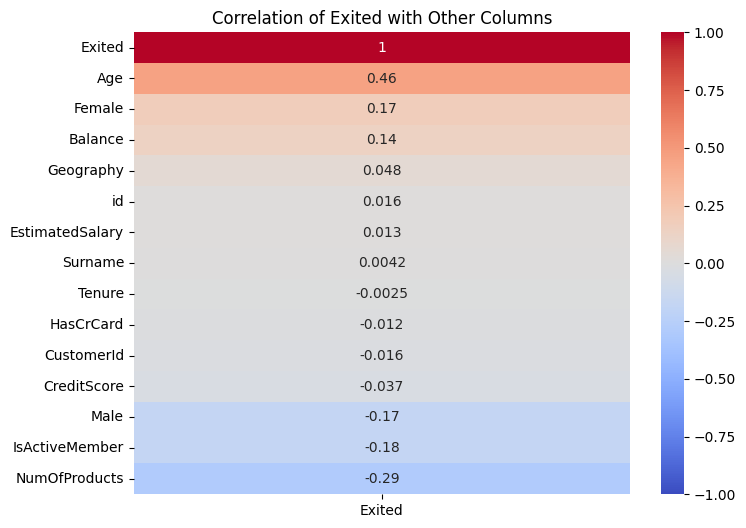

In [ ]:
corr_matrix = df.corr()

ten_year_chd_corr = corr_matrix[['Exited']].sort_values(by='Exited', ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ten_year_chd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Exited with Other Columns')
plt.show()

<Axes: ylabel='Age'>

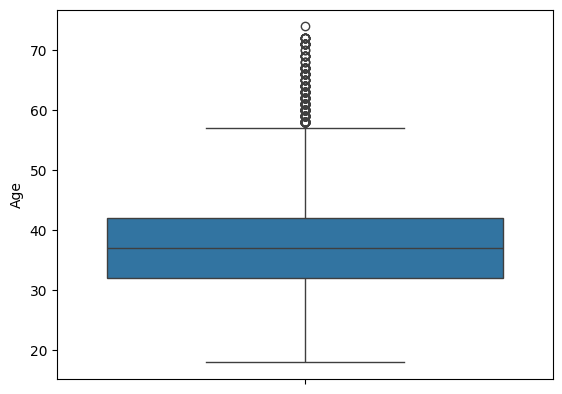

In [ ]:
sns.boxplot(df['Age'])

<Axes: ylabel='Balance'>

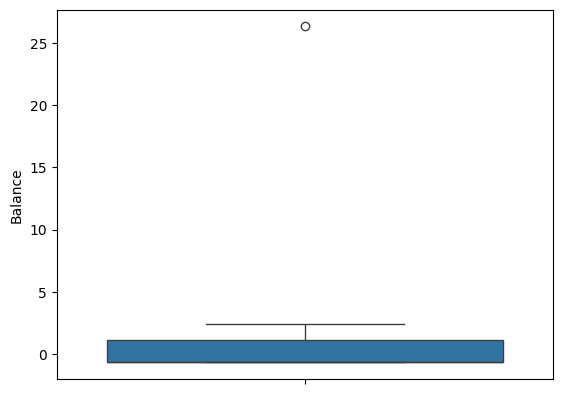

In [ ]:
sns.boxplot(df['Balance'])

<Axes: ylabel='EstimatedSalary'>

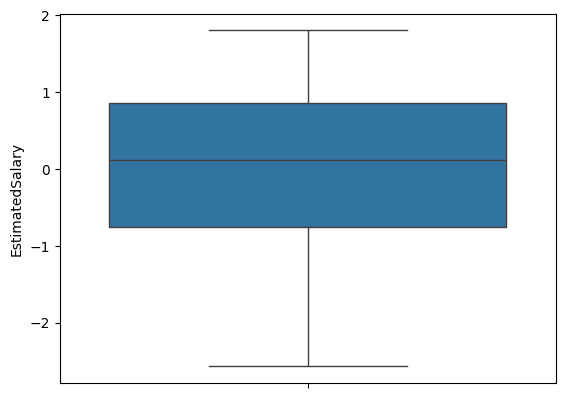

In [ ]:
sns.boxplot(df['EstimatedSalary'])

In [ ]:
q1_age =df['Age'].quantile(0.25)
q3_age =df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

In [ ]:
df.shape

(15000, 15)

In [ ]:
df.loc[ df['Age'] > upper_bound_age, 'Age'] = upper_bound_age
df.loc[ df['Age'] < lower_bound_age, 'Age'] = lower_bound_age

<Axes: ylabel='Age'>

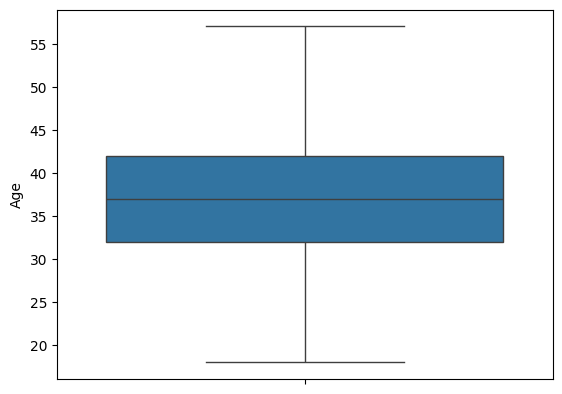

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,707,667,0,33,5,-0.706360,2,1,1,0.613584,0.0,0,1
1,1,15803032.0,299,653,1,34,1,1.773477,1,1,0,-1.082984,0.0,1,0
2,2,15631170.0,707,656,0,30,5,-0.706360,2,1,0,-1.059360,0.0,0,1
3,3,15761733.0,73,704,0,40,1,-0.706360,1,1,1,1.050888,0.0,0,1
4,4,15682070.0,422,642,0,32,2,-0.706360,2,1,0,-2.556519,0.0,0,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["CustomerId"]=le.fit_transform(df["CustomerId"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1137,707,667,0,33,5,-0.706360,2,1,1,0.613584,0.0,0,1
1,1,6042,299,653,1,34,1,1.773477,1,1,0,-1.082984,0.0,1,0
2,2,1534,707,656,0,30,5,-0.706360,2,1,0,-1.059360,0.0,0,1
3,3,4882,73,704,0,40,1,-0.706360,1,1,1,1.050888,0.0,0,1
4,4,2907,422,642,0,32,2,-0.706360,2,1,0,-2.556519,0.0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 1498
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  int64  
 2   Surname          15000 non-null  int64  
 3   CreditScore      15000 non-null  int64  
 4   Geography        15000 non-null  int64  
 5   Age              15000 non-null  int64  
 6   Tenure           15000 non-null  int64  
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  int64  
 9   HasCrCard        15000 non-null  int64  
 10  IsActiveMember   15000 non-null  int64  
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           13501 non-null  float64
 13  Female           15000 non-null  int64  
 14  Male             15000 non-null  int64  
dtypes: float64(3), int64(12)
memory usage: 1.8 MB


In [ ]:
train_new=df.iloc[:13501]

train_new.shape

(13501, 15)

In [ ]:
train_new.shape


(13501, 15)

In [ ]:
test_new=df.iloc[13501:]
test_new.shape

(1499, 15)

In [ ]:
train_new

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1137,707,667,0,33,5,-0.706360,2,1,1,0.613584,0.0,0,1
1,1,6042,299,653,1,34,1,1.773477,1,1,0,-1.082984,0.0,1,0
2,2,1534,707,656,0,30,5,-0.706360,2,1,0,-1.059360,0.0,0,1
3,3,4882,73,704,0,40,1,-0.706360,1,1,1,1.050888,0.0,0,1
4,4,2907,422,642,0,32,2,-0.706360,2,1,0,-2.556519,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13496,13496,2768,162,589,2,35,4,0.951822,1,1,0,0.572465,0.0,0,1
13497,13497,5889,700,744,2,34,8,-0.706360,1,1,1,-2.329542,0.0,0,1
13498,13498,3624,295,745,0,36,9,-0.706360,1,0,1,-1.172270,1.0,1,0
13499,13499,3903,301,659,2,37,9,1.409473,1,0,1,1.661844,0.0,0,1


In [ ]:
test_new

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,13501,3356,382,697,2,26,6,-0.706360,2,0,1,0.969635,NaN,0,1
1,13502,190,92,651,0,41,9,-0.706360,1,1,1,1.203133,NaN,1,0
2,13503,5534,670,593,1,33,1,1.213916,1,1,0,-0.345620,NaN,1,0
3,13504,2561,652,559,2,36,1,-0.706360,2,1,0,-0.568215,NaN,0,1
4,13505,6126,753,619,0,34,0,-0.706360,2,0,1,0.085309,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,14995,3238,341,588,0,43,3,-0.706360,1,1,0,1.005171,NaN,1,0
1495,14996,2662,45,594,1,40,8,1.514830,1,1,0,0.618703,NaN,0,1
1496,14997,5975,297,684,0,52,6,1.679603,3,1,0,-0.595196,NaN,0,1
1497,14998,3298,298,684,2,45,3,-0.706360,1,1,0,-0.249385,NaN,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x_train=train_new.drop('Exited', axis=1)
y_train=train_new['Exited']

x_test=test_new.drop('Exited', axis=1)




In [ ]:
log = LogisticRegression(max_iter=1000, random_state=1)
log.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
y_pred = log.predict(x_test)

In [ ]:
y_pred

array([0., 0., 0., ..., 0., 0., 1.])

In [ ]:
y_pred=pd.DataFrame(y_pred)
y_pred

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1494,1.0
1495,0.0
1496,0.0
1497,0.0


In [ ]:
y_pred[0].value_counts()

,count
0,
0.0,1287
1.0,212


In [ ]:
submission={'id':test_new['id'],'Exited':y_pred[0]}
submission=pd.DataFrame(submission)
submission

,id,Exited
0,13501,0.0
1,13502,0.0
2,13503,0.0
3,13504,0.0
4,13505,0.0
...,...,...
1494,14995,1.0
1495,14996,0.0
1496,14997,0.0
1497,14998,0.0


In [ ]:
submission

,id,Exited
0,13501,0.0
1,13502,0.0
2,13503,0.0
3,13504,0.0
4,13505,0.0
...,...,...
1494,14995,1.0
1495,14996,0.0
1496,14997,0.0
1497,14998,0.0


In [ ]:
train_new

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1137,707,667,0,33,5,-0.706360,2,1,1,0.613584,0.0,0,1
1,1,6042,299,653,1,34,1,1.773477,1,1,0,-1.082984,0.0,1,0
2,2,1534,707,656,0,30,5,-0.706360,2,1,0,-1.059360,0.0,0,1
3,3,4882,73,704,0,40,1,-0.706360,1,1,1,1.050888,0.0,0,1
4,4,2907,422,642,0,32,2,-0.706360,2,1,0,-2.556519,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13496,13496,2768,162,589,2,35,4,0.951822,1,1,0,0.572465,0.0,0,1
13497,13497,5889,700,744,2,34,8,-0.706360,1,1,1,-2.329542,0.0,0,1
13498,13498,3624,295,745,0,36,9,-0.706360,1,0,1,-1.172270,1.0,1,0
13499,13499,3903,301,659,2,37,9,1.409473,1,0,1,1.661844,0.0,0,1


In [ ]:
train_new_X= train_new.drop('Exited', axis=1)

In [ ]:
train_new_y= train_new['Exited']

In [ ]:
x_new_train,x_new_test,y_new_train,y_new_test = train_test_split(train_new_X,train_new_y,test_size=0.3,random_state=1)

In [ ]:
log.fit(x_new_train, y_new_train)

LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
y_new_pred=log.predict(x_new_test)

In [ ]:
accuracy_score(y_new_test, y_new_pred)

0.8750925697358677

In [ ]:
from sklearn.ensemble import RandomForestClassifier

randomforest=RandomForestClassifier(n_estimators=100)
randomforest.fit(x_new_train, y_new_train)

RandomForestClassifier()

In [ ]:
y_new_pred=randomforest.predict(x_new_test)

In [ ]:
accuracy_score(y_new_test, y_new_pred)

0.8955813379412491

In [ ]:
randomforest.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_new=randomforest.predict(x_test)

In [ ]:
y_pred_new

array([0., 0., 0., ..., 1., 1., 1.])

In [ ]:
y_pred_new=pd.DataFrame(y_pred_new)
y_pred_new

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1494,1.0
1495,0.0
1496,1.0
1497,1.0


In [ ]:
y_pred_new[0].value_counts()

,count
0,
0.0,1251
1.0,248


In [ ]:
submission_new={'id':test_new['id'],'Exited':y_pred_new[0]}
submission_new=pd.DataFrame(submission_new)
submission_new

,id,Exited
0,13501,0.0
1,13502,0.0
2,13503,0.0
3,13504,0.0
4,13505,0.0
...,...,...
1494,14995,1.0
1495,14996,0.0
1496,14997,1.0
1497,14998,1.0


In [ ]:
submission_new.to_csv('submission_new.csv', index=False)

In [ ]:
pd.read_csv('submission_new.csv')

,id,Exited
0,13501,0.0
1,13502,0.0
2,13503,0.0
3,13504,0.0
4,13505,0.0
...,...,...
1494,14995,1.0
1495,14996,0.0
1496,14997,1.0
1497,14998,1.0


In [ ]:
submission_new['Exited'].value_counts()

,count
Exited,
0.0,1251
1.0,248


In [ ]:
!kaggle competitions submit -c problem2-used-car-price-prediction -f submission_new.csv -m "Message"

100% 14.6k/14.6k [00:00<00:00, 31.6kB/s]
Successfully submitted to Bank Customer Churn Prediction